# Detect Missing Trees — Interior Gap Detection

In [56]:
import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import utm
from scipy.spatial import KDTree

from fetch_tree_surveys import get_latest_survey, get_all_tree_surveys, add_utm_coordinates

ORCHARD_ID = 216269

## 1. Fetch data and convert to UTM

In [57]:
survey = get_latest_survey(ORCHARD_ID)
print(f"Survey: {survey['id']} (date: {survey['date']})")

tree_surveys = get_all_tree_surveys(survey["id"])
add_utm_coordinates(tree_surveys)
print(f"Total trees: {len(tree_surveys)}")

valid_trees = [
    t for t in tree_surveys
    if t.get("utm_easting") is not None and t.get("utm_northing") is not None
]
points = np.array([[t["utm_easting"], t["utm_northing"]] for t in valid_trees])
print(f"Valid trees with UTM coords: {len(valid_trees)}")

Survey: 25319 (date: 2019-05-03)
Total trees: 508
Valid trees with UTM coords: 508


## 2. Determine row orientation

For each tree, compute angles to its k nearest neighbours. The histogram is used to determine the most popular angle of each tree with their neighbour.

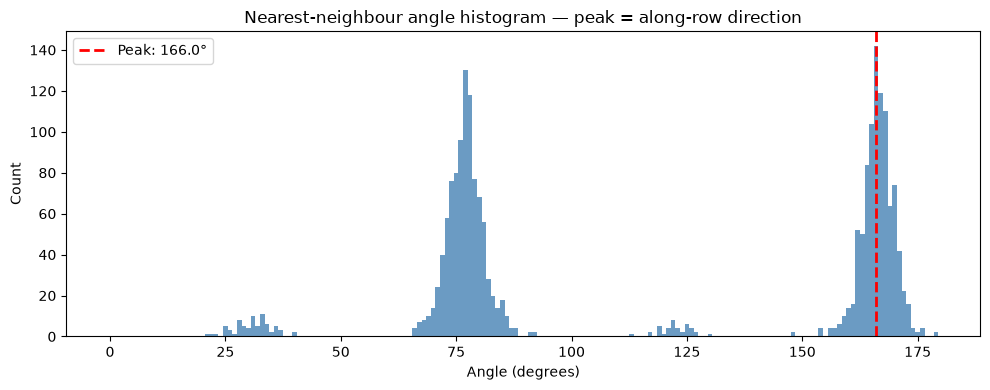

Row angle: 166.0°
Along-row vector: [-0.9703, 0.2419]
Across-row vector: [-0.2419, -0.9703]


In [58]:
# number of neighbours, we assume trees are planted in a (approximate) grid formation
k = 4 

# build a structure to organise the data based the coordinates
# effectively building a k-nearest neighbout graph where it can efficiently query
# for neighbours that are close to the given point
kdtree = KDTree(points)

# find neighbours for each point (need k+1 since current point has distance 0)
_, indices = kdtree.query(points, k=k+1)

# calculate the angles between each tree in the survey and four of its neighbours
angles = []
for i, neighbors in enumerate(indices):
    for j in neighbors[1:]:  # skip self
        dx = points[j, 0] - points[i, 0]
        dy = points[j, 1] - points[i, 1]
        angle = math.atan2(dy, dx) % math.pi # pi == 180 degrees, radials used by default
        angles.append(angle)

# have each degree be its own bucket
bin_count = 180
hist, bin_edges = np.histogram(angles, bins=bin_count, range=(0, math.pi))

# find the bin with the largest count
# the idea here is that the histogram with the greatest angle
# is more likely to be in the same row (think two points on a line, the angle would be 180 degrees)
peak_bin = np.argmax(hist)
row_angle = bin_edges[peak_bin]

# determine the orientation of the row
along_row = np.array([math.cos(row_angle), math.sin(row_angle)])

# determine the direction perpendicular to row orientation
across_row = np.array([-math.sin(row_angle), math.cos(row_angle)])

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.degrees(bin_edges[:-1]), hist, width=180 / bin_count, color="steelblue", alpha=0.8)
ax.axvline(math.degrees(row_angle), color="red", linestyle="--", linewidth=2, label=f"Peak: {math.degrees(row_angle):.1f}°")
ax.set_xlabel("Angle (degrees)")
ax.set_ylabel("Count")
ax.set_title("Nearest-neighbour angle histogram — peak = along-row direction")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Row angle: {math.degrees(row_angle):.1f}°")
print(f"Along-row vector: [{along_row[0]:.4f}, {along_row[1]:.4f}]")
print(f"Across-row vector: [{across_row[0]:.4f}, {across_row[1]:.4f}]")

## 3. Estimate row spacing

Project all trees onto the across-row axis. The projection histogram shows peaks where rows are, the clusters of bars should indicate rows.

/var/folders/vb/6m4rff3j6lnbn004kr_511_c0000gp/T/ipykernel_65323/553468752.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


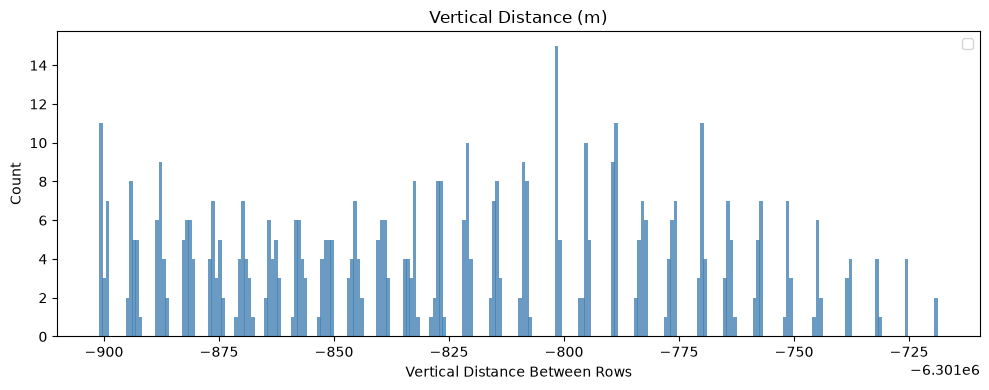

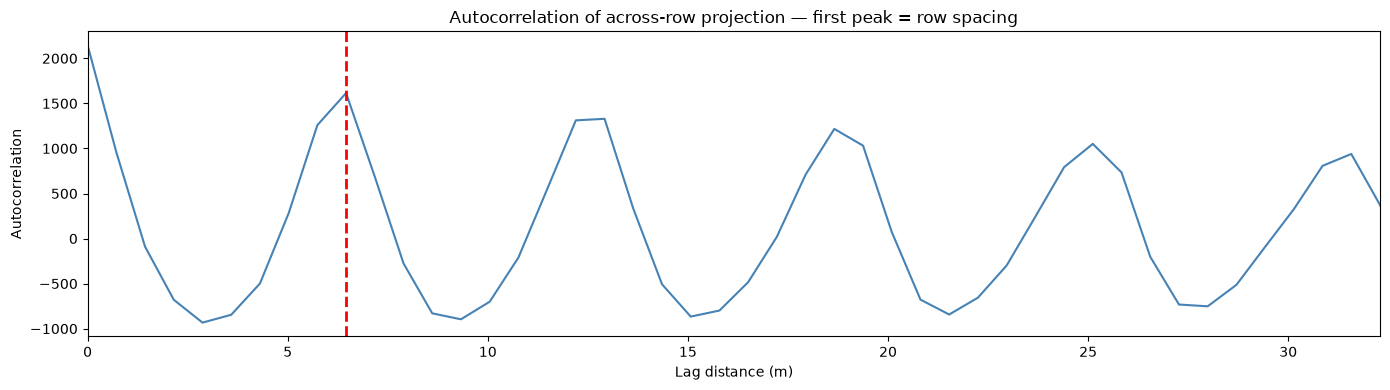

Estimated row spacing: 6.46m


In [ ]:
# collapse points to a scalar value, representing collapsing the points to across-row axis (imagine collapsing point (x,y) to (0,y) in a cartesian coordinate system)
projections_across = points @ across_row

# random: not super strong argument for number of bins
bins = max(100, len(points) // 2)

# compute histogram
hist, bins = np.histogram(projections_across, bins=bins)

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bins[:-1], hist, color="steelblue", alpha=0.8)
ax.set_xlabel("Vertical Distance Between Rows")
ax.set_ylabel("Count")
ax.set_title("Vertical Distance (m)")
ax.legend()
plt.tight_layout()
plt.show()

bin_width = bins[1] - bins[0]

# get centre of each bin
centres = (bins[:-1] + bins[1:]) / 2

# Autocorrelation to find periodic row spacing
# The idea here is that we slide the histogram over itself 
# and calculating the sum of products between each count 
# of each bin in the histogram
hist_centered = hist - hist.mean()
autocorr = np.correlate(hist_centered, hist_centered, mode="full")
autocorr = autocorr[len(autocorr) // 2:]  # positive lags only

min_lag = max(1, int(1.0 / bin_width))
peaks = []
for i in range(min_lag, len(autocorr) - 1):
    if autocorr[i] > autocorr[i - 1] and autocorr[i] > autocorr[i + 1]:
        peaks.append((i, autocorr[i]))

if peaks:
    best_peak = max(peaks, key=lambda p: p[1])
    row_spacing = best_peak[0] * bin_width
else:
    row_spacing = np.median(np.diff(np.sort(projections_across)))

fig, axes = plt.subplots(1, 1, figsize=(14, 4))

# Autocorrelation
lag_distances = np.arange(len(autocorr)) * bin_width
axes.plot(lag_distances, autocorr, color="steelblue")
axes.axvline(row_spacing, color="red", linestyle="--", linewidth=2, label=f"Row spacing: {row_spacing:.2f}m")
axes.set_xlabel("Lag distance (m)")
axes.set_ylabel("Autocorrelation")
axes.set_title("Autocorrelation of across-row projection")
axes.set_xlim(0, row_spacing * 5)

plt.tight_layout()
plt.show()

print(f"Estimated row spacing: {row_spacing:.2f}m")

## 4. Cluster trees into rows

Determine rows by grouping together values with similar projections and then use the row spacing to determine different rows.

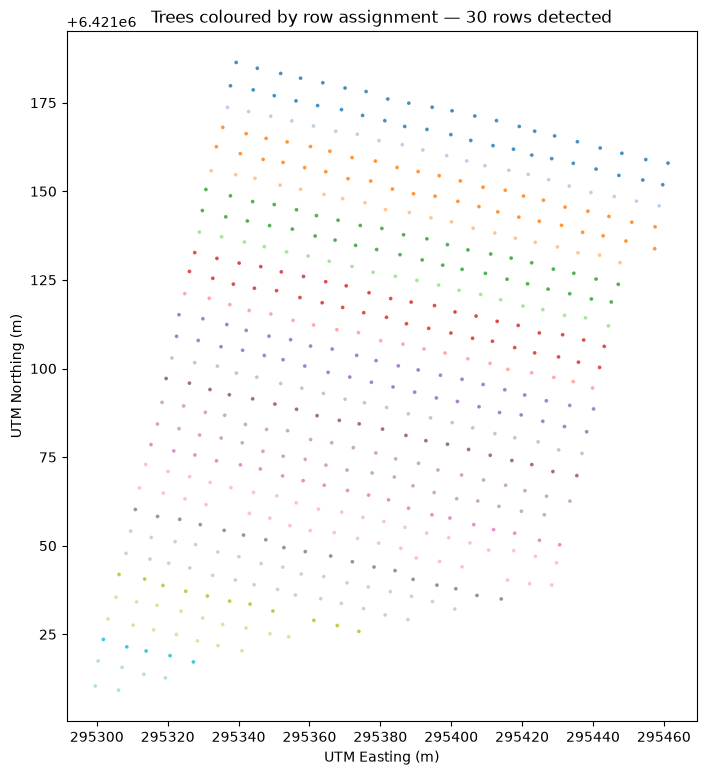

Rows detected: 30
Trees per row — min: 2, max: 21, median: 20


In [ ]:
threshold = row_spacing * 0.4

# group projections together if the distance between them is less than the threshold

sorted_idx = np.argsort(projections_across)
sorted_projections = projections_across[sorted_idx]

# used to map a projection to a row given the index of the projection
sorted_row_labels = np.zeros_like(sorted_projections, dtype=int)

curr_row_label = 0
sorted_row_labels[0] = curr_row_label
for i in range(1, len(sorted_projections)):
    # since we've sorted the projection, the first value for which this 
    # is true will be the first projection of the next row
    if (sorted_projections[i] - sorted_projections[i-1]) > threshold:
        curr_row_label += 1
    sorted_row_labels[i] = curr_row_label
    
row_labels = np.zeros_like(sorted_projections, dtype=int)
row_labels[sorted_idx] = sorted_row_labels
num_rows = len(set(row_labels))
row_sizes = [np.sum(row_labels == r) for r in set(row_labels)]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(points[:, 0], points[:, 1], c=row_labels, cmap="tab20", s=3, alpha=0.7)
ax.set_xlabel("UTM Easting (m)")
ax.set_ylabel("UTM Northing (m)")
ax.set_title(f"Trees coloured by row assignment — {num_rows} rows detected")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"Rows detected: {num_rows}")
print(f"Trees per row — min: {min(row_sizes)}, max: {max(row_sizes)}, median: {np.median(row_sizes):.0f}")

## 5. Detect gaps within rows

For each row, sort trees by along-row projection and compute consecutive distances. The histogram of inter-tree distances should show a tight cluster around the typical in-row spacing. Gaps that are ~2x, 3x, etc. the mean spacing indicate missing trees.

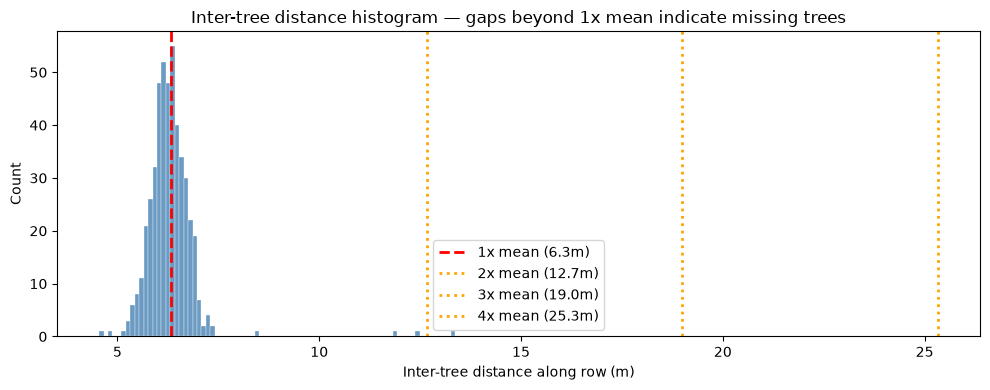

Mean in-row tree spacing: 6.33m


In [61]:
# build row index to group trees by their row label
row_index = defaultdict(list)
for tree, label in zip(valid_trees, row_labels):
    row_index[label].append(tree)

# collect all inter-tree distances across all rows for the histogram
all_distances = []
mean_spacings = []

# for each row, calculate the pair-wise distance between the trees and determine the average distance
for row_label, trees in sorted(row_index.items()):
    # need at least three trees to establish meaningful pattern
    if len(trees) < 3:
        continue

    # collect the UTM positions
    tree_positions = []
    for t in trees:
        pos = np.array([t["utm_easting"], t["utm_northing"]])
        proj = np.dot(pos, along_row)
        tree_positions.append(proj)
    tree_positions.sort()

    # calculate pairwise distance between each tree
    distances = np.diff(tree_positions)

    all_distances.extend(distances)
    mean_spacings.append(np.mean(distances))

overall_mean_spacing = np.mean(mean_spacings)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_distances, bins=80, color="steelblue", alpha=0.8, edgecolor="white", linewidth=0.3)
for mult in range(1, 5):
    color = "red" if mult == 1 else "orange"
    style = "--" if mult == 1 else ":"
    ax.axvline(overall_mean_spacing * mult, color=color, linestyle=style, linewidth=2,
               label=f"{mult}x mean ({overall_mean_spacing * mult:.1f}m)")
ax.set_xlabel("Inter-tree distance along row (m)")
ax.set_ylabel("Count")
ax.set_title("Inter-tree distance histogram — gaps beyond 1x mean indicate missing trees")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean in-row tree spacing: {overall_mean_spacing:.2f}m")

## 6. Interpolate missing tree positions and plot results

In [62]:
def lerp(a, b, t):
    if a is None or b is None:
        return None
    return float(a) + (float(b) - float(a)) * t

missing_trees = []

for row_label, trees in sorted(row_index.items()):
    if len(trees) < 3:
        continue

    tree_positions = []
    for t in trees:
        pos = np.array([t["utm_easting"], t["utm_northing"]])
        proj = np.dot(pos, along_row)
        tree_positions.append((proj, t))
    tree_positions.sort(key=lambda x: x[0])

    distances = []
    for i in range(len(tree_positions) - 1):
        d = tree_positions[i + 1][0] - tree_positions[i][0]
        distances.append(d)

    mean_spacing = np.mean(distances)
    if mean_spacing <= 0:
        continue

    for i, d in enumerate(distances):
        n_missing = round(d / mean_spacing) - 1
        if n_missing <= 0:
            continue

        tree_before = tree_positions[i][1]
        tree_after = tree_positions[i + 1][1]

        for k in range(1, n_missing + 1):
            t = k / (n_missing + 1)
            lat = lerp(tree_before["lat"], tree_after["lat"], t)
            lng = lerp(tree_before["lng"], tree_after["lng"], t)
            utm_e = lerp(tree_before["utm_easting"], tree_after["utm_easting"], t)
            utm_n = lerp(tree_before["utm_northing"], tree_after["utm_northing"], t)

            missing_trees.append({
                "row": int(row_label),
                "lat": lat,
                "lng": lng,
                "utm_easting": utm_e,
                "utm_northing": utm_n,
                "gap_between": [tree_before["id"], tree_after["id"]],
                "estimated_spacing": round(mean_spacing, 2),
                "actual_gap": round(d, 2),
            })

print(f"Missing trees detected: {len(missing_trees)}")

rows_with_gaps = defaultdict(int)
for m in missing_trees:
    print(m)
    rows_with_gaps[m["row"]] += 1
for row, count in sorted(rows_with_gaps.items()):
    print(f"  Row {row}: {count} missing")

Missing trees detected: 3
{'row': 20, 'lat': -32.328802550000006, 'lng': 18.82642915, 'utm_easting': 295409.4884492378, 'utm_northing': 6421042.173499783, 'gap_between': [54733001, 54733007], 'estimated_spacing': np.float64(7.03), 'actual_gap': np.float64(13.37)}
{'row': 20, 'lat': -32.328625450000004, 'lng': 18.8256628, 'utm_easting': 295336.94099146273, 'utm_northing': 6421060.346146654, 'gap_between': [54733417, 54733139], 'estimated_spacing': np.float64(7.03), 'actual_gap': np.float64(12.44)}
{'row': 24, 'lat': -32.328900149999996, 'lng': 18.825853, 'utm_easting': 295355.4659877274, 'utm_northing': 6421030.250247333, 'gap_between': [54733069, 54733067], 'estimated_spacing': np.float64(6.95), 'actual_gap': np.float64(11.86)}
  Row 20: 2 missing
  Row 24: 1 missing


## 7. Detect edge missing trees (start/end of rows)

The interior gap algorithm can only find gaps *between* existing trees. Trees missing at the start or end of a row are invisible to it.

**Approach:** sort rows by across-row position (top to bottom) and scan with a stride of 3. For each triplet (top, middle, bottom), compute the "effective count" — real trees + interior missing trees already detected. If top and bottom agree on count but the middle row is short, the deficit must be at the edges. Compare the along-row projections of the first/last trees to determine whether the missing trees are at the start, end, or both.

In [63]:
# Build per-row data: sorted along-row projections and effective counts
# (real trees + interior missing trees already detected)

interior_missing_per_row = defaultdict(int)
for m in missing_trees:
    interior_missing_per_row[m["row"]] += 1

row_data = {}
for row_label, trees in row_index.items():
    if len(trees) < 3:
        continue
    projs = []
    for t in trees:
        pos = np.array([t["utm_easting"], t["utm_northing"]])
        projs.append(np.dot(pos, along_row))
    projs.sort()

    # Across-row position of this row (for sorting rows top-to-bottom)
    across_proj = np.mean([
        np.dot(np.array([t["utm_easting"], t["utm_northing"]]), across_row)
        for t in trees
    ])

    effective_count = len(trees) + interior_missing_per_row[row_label]
    mean_spacing_row = np.mean(np.diff(projs))

    row_data[row_label] = {
        "across_proj": across_proj,
        "along_projs": projs,
        "start": projs[0],
        "end": projs[-1],
        "real_count": len(trees),
        "effective_count": effective_count,
        "mean_spacing": mean_spacing_row,
        "trees": trees,
    }

# Sort rows by across-row projection (top to bottom)
sorted_row_labels = sorted(row_data.keys(), key=lambda r: row_data[r]["across_proj"])

print(f"Rows sorted by across-row position: {len(sorted_row_labels)}")
print(f"Effective counts: {[row_data[r]['effective_count'] for r in sorted_row_labels]}")

Rows sorted by across-row position: 29
Effective counts: [21, 21, 21, 21, 21, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 19, 20, 20, 20, 18, 16, 14, 12, 9, 7, 5, 4]


In [64]:
# Scan rows in triplets (top, middle, bottom)
# Every row (except the first and last) gets checked as the "middle" of a triplet

# Get UTM zone from an existing tree for inverse conversion
sample_tree = valid_trees[0]
utm_zone_number = sample_tree["utm_zone_number"]
utm_zone_letter = sample_tree["utm_zone_letter"]

edge_missing_trees = []

for i in range(1, len(sorted_row_labels) - 1):
    top_label = sorted_row_labels[i - 1]
    mid_label = sorted_row_labels[i]
    bot_label = sorted_row_labels[i + 1]

    top = row_data[top_label]
    mid = row_data[mid_label]
    bot = row_data[bot_label]

    # Do top and bottom agree on effective count, but middle is short?
    expected_count = min(top["effective_count"], bot["effective_count"])
    deficit = expected_count - mid["effective_count"]
    if deficit <= 0:
        continue

    # Use mean spacing from the middle row for interpolation
    spacing = mid["mean_spacing"]
    if spacing <= 0:
        continue

    # Check the START: is the middle row's first tree shifted inward
    # compared to where top and bottom start?
    ref_start = min(top["start"], bot["start"])
    start_gap = mid["start"] - ref_start
    missing_at_start = max(0, round(start_gap / spacing))

    # Check the END: is the middle row's last tree shifted inward?
    ref_end = max(top["end"], bot["end"])
    end_gap = ref_end - mid["end"]
    missing_at_end = max(0, round(end_gap / spacing))

    # Clamp so we don't exceed the deficit
    total_edge = missing_at_start + missing_at_end
    if total_edge > deficit:
        scale = deficit / total_edge
        missing_at_start = round(missing_at_start * scale)
        missing_at_end = deficit - missing_at_start

    # Interpolate missing positions at the start of the row
    if missing_at_start > 0:
        first_tree = mid["trees"][
            np.argmin([np.dot(np.array([t["utm_easting"], t["utm_northing"]]), along_row) for t in mid["trees"]])
        ]
        for k in range(1, missing_at_start + 1):
            utm_e = first_tree["utm_easting"] - k * spacing * along_row[0]
            utm_n = first_tree["utm_northing"] - k * spacing * along_row[1]
            lat, lng = utm.to_latlon(utm_e, utm_n, utm_zone_number, utm_zone_letter)
            edge_missing_trees.append({
                "row": int(mid_label),
                "lat": lat,
                "lng": lng,
                "utm_easting": utm_e,
                "utm_northing": utm_n,
                "edge": "start",
                "estimated_spacing": round(spacing, 2),
            })

    # Interpolate missing positions at the end of the row
    if missing_at_end > 0:
        last_tree = mid["trees"][
            np.argmax([np.dot(np.array([t["utm_easting"], t["utm_northing"]]), along_row) for t in mid["trees"]])
        ]
        for k in range(1, missing_at_end + 1):
            utm_e = last_tree["utm_easting"] + k * spacing * along_row[0]
            utm_n = last_tree["utm_northing"] + k * spacing * along_row[1]
            lat, lng = utm.to_latlon(utm_e, utm_n, utm_zone_number, utm_zone_letter)
            edge_missing_trees.append({
                "row": int(mid_label),
                "lat": lat,
                "lng": lng,
                "utm_easting": utm_e,
                "utm_northing": utm_n,
                "edge": "end",
                "estimated_spacing": round(spacing, 2),
            })

print(f"Edge missing trees detected: {len(edge_missing_trees)}")
print(f"  At start of row: {sum(1 for m in edge_missing_trees if m['edge'] == 'start')}")
print(f"  At end of row: {sum(1 for m in edge_missing_trees if m['edge'] == 'end')}")

edge_rows = defaultdict(lambda: {"start": 0, "end": 0})
for m in edge_missing_trees:
    edge_rows[m["row"]][m["edge"]] += 1
for row, counts in sorted(edge_rows.items()):
    print(f"  Row {row}: {counts['start']} at start, {counts['end']} at end")

Edge missing trees detected: 1
  At start of row: 1
  At end of row: 0
  Row 17: 1 at start, 0 at end


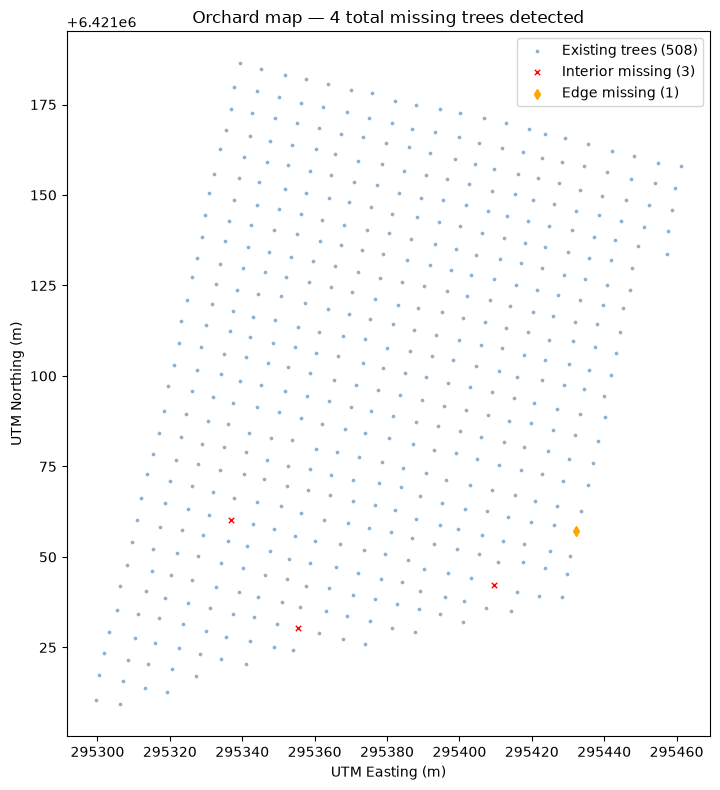

Total missing: 4 (interior: 3, edge: 1)


In [65]:
all_missing = missing_trees + edge_missing_trees

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(points[:, 0], points[:, 1], c="steelblue", s=3, alpha=0.5, label=f"Existing trees ({len(points)})")

if missing_trees:
    interior_pts = np.array([[m["utm_easting"], m["utm_northing"]] for m in missing_trees])
    ax.scatter(interior_pts[:, 0], interior_pts[:, 1], c="red", s=15, marker="x",
               linewidths=1, label=f"Interior missing ({len(missing_trees)})")

if edge_missing_trees:
    edge_pts = np.array([[m["utm_easting"], m["utm_northing"]] for m in edge_missing_trees])
    ax.scatter(edge_pts[:, 0], edge_pts[:, 1], c="orange", s=25, marker="d",
               linewidths=1, label=f"Edge missing ({len(edge_missing_trees)})")

ax.set_xlabel("UTM Easting (m)")
ax.set_ylabel("UTM Northing (m)")
ax.set_title(f"Orchard map — {len(all_missing)} total missing trees detected")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total missing: {len(all_missing)} (interior: {len(missing_trees)}, edge: {len(edge_missing_trees)})")

In [66]:
missing_trees

[{'row': 20,
  'lat': -32.328802550000006,
  'lng': 18.82642915,
  'utm_easting': 295409.4884492378,
  'utm_northing': 6421042.173499783,
  'gap_between': [54733001, 54733007],
  'estimated_spacing': np.float64(7.03),
  'actual_gap': np.float64(13.37)},
 {'row': 20,
  'lat': -32.328625450000004,
  'lng': 18.8256628,
  'utm_easting': 295336.94099146273,
  'utm_northing': 6421060.346146654,
  'gap_between': [54733417, 54733139],
  'estimated_spacing': np.float64(7.03),
  'actual_gap': np.float64(12.44)},
 {'row': 24,
  'lat': -32.328900149999996,
  'lng': 18.825853,
  'utm_easting': 295355.4659877274,
  'utm_northing': 6421030.250247333,
  'gap_between': [54733069, 54733067],
  'estimated_spacing': np.float64(6.95),
  'actual_gap': np.float64(11.86)}]

In [67]:
edge_missing_trees

[{'row': 17,
  'lat': np.float64(-32.32867109033987),
  'lng': np.float64(18.826674746960087),
  'utm_easting': np.float64(295432.3146047083),
  'utm_northing': np.float64(6421057.219340969),
  'edge': 'start',
  'estimated_spacing': np.float64(6.23)}]